In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
titanic = sns.load_dataset("titanic")

In [3]:
titanic.head(15)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [4]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
features = ["pclass","sex","fare","embarked","age"]
target = ["survived"]

In [7]:
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy = "median")

titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_most = SimpleImputer(strategy = "most_frequent")

titanic[["embarked"]] = imp_most.fit_transform(titanic[["embarked"]])

In [8]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [9]:
X = titanic[features]
y= titanic["survived"]

In [10]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y, test_size=0.2,random_state=42
)

In [11]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [12]:
y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score

print("Accuracy : ", accuracy_score(y_test,y_pred))

Accuracy :  0.770949720670391


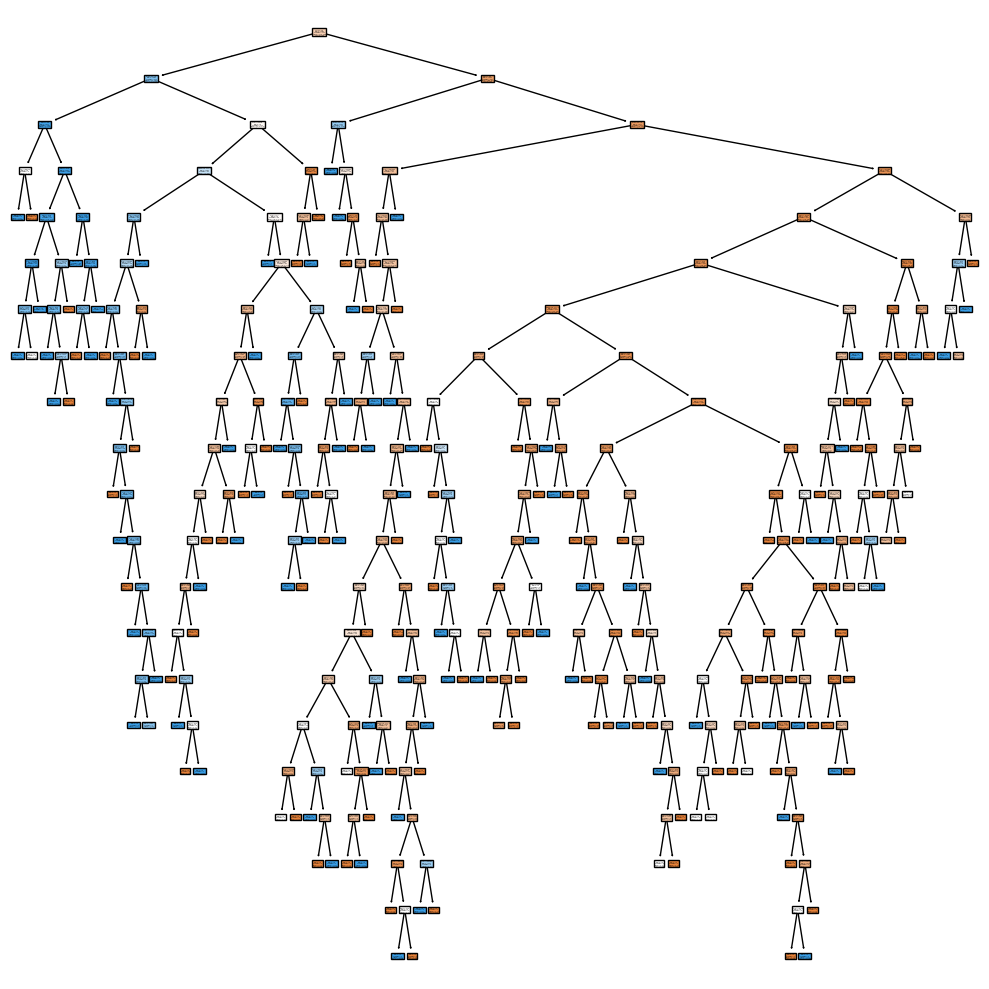

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)
plt.tight_layout()
plt.show()

For depth = 2, Accuracy = 0.7654
For depth = 3, Accuracy = 0.7989
For depth = 4, Accuracy = 0.7989


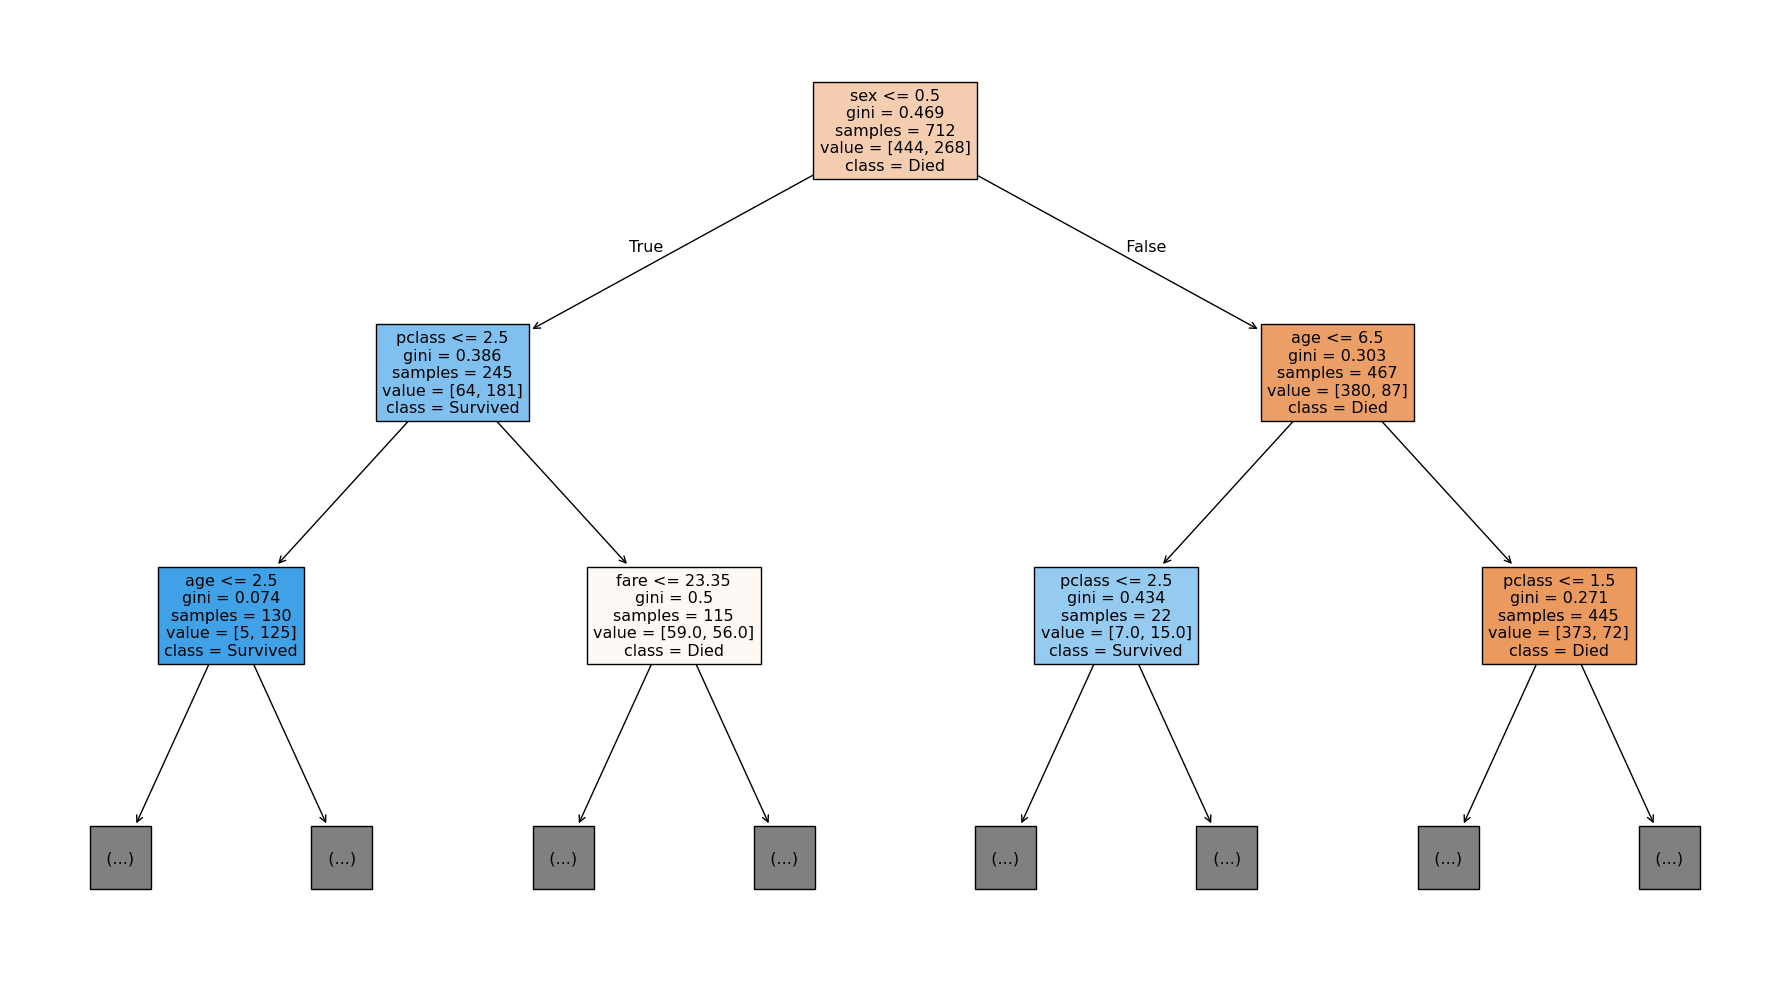

For depth = 5, Accuracy = 0.7989
For depth = 6, Accuracy = 0.8045
For depth = 7, Accuracy = 0.7877
For depth = 8, Accuracy = 0.7933
For depth = 9, Accuracy = 0.7933
For depth = 10, Accuracy = 0.7989


In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"For depth = {depth}, Accuracy = {acc:.4f}")

    if depth == 4:
        plt.figure(figsize=(18, 10))

        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True,
            max_depth=2
        )

        plt.tight_layout()
        plt.show()

In [16]:
from sklearn.tree import DecisionTreeClassifier

splits = [2, 4, 6, 8, 10, 12, 15, 20]

for split in splits:
    model = DecisionTreeClassifier(
        max_depth=4,
        min_samples_split=split,
        random_state=42
    )

    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"For min_samples_split = {split}, Accuracy = {acc:.4f}")

For min_samples_split = 2, Accuracy = 0.7989
For min_samples_split = 4, Accuracy = 0.7989
For min_samples_split = 6, Accuracy = 0.7989
For min_samples_split = 8, Accuracy = 0.7989
For min_samples_split = 10, Accuracy = 0.7989
For min_samples_split = 12, Accuracy = 0.7989
For min_samples_split = 15, Accuracy = 0.7989
For min_samples_split = 20, Accuracy = 0.7989


In [17]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [18]:
path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas=path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [19]:
trees=[]

for i in ccp_alphas:
    model=DecisionTreeClassifier(random_state=42,ccp_alpha=i)
    model.fit(X_train,y_train)

    acc = model.score(X_train,y_train)

    trees.append((model,i))

In [20]:
best_acc = 0
best_alpha = 0
best_model = None

for model, alpha in trees:
    curr_acc = model.score(X_test, y_test)

    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha
        best_model = model

print(f"Best alpha: {best_alpha}")
print(f"Best Accuracy: {best_acc:.4f}")

Best alpha: 0.0015407231242023183
Best Accuracy: 0.8380


In [29]:
from sklearn.ensemble import RandomForestClassifier 

rf =RandomForestClassifier(
    n_estimators=300,
    oob_score=True
)

rf.fit(X_train,y_train)

y_pred = rf.predict(X_test)
y_pred_t =rf.predict(X_train)

print(rf.oob_score_ * 100,"%")
print(accuracy_score(y_test,y_pred)*100 , "%")
print(accuracy_score(y_train,y_pred_t)*100 , "%")

79.63483146067416 %
79.88826815642457 %
97.75280898876404 %
